In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, f_classif, chi2

## Carga dataset

In [77]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")
test_df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv")
df_crimes.head()

columns_to_drop = ['Arrest_tag', 'Unnamed: 0']
location_features_to_drop = ['Ward', 'Latitude', 'Longitude', 'Nearest_Police_Station_District_Name_freq', 
                             'Community Area', 'Crime_District_freq', 'Nearest_Police_Station_District_freq']
X_train_final = df_crimes.drop(columns=columns_to_drop+location_features_to_drop)
y_train_encoded = df_crimes['Arrest_tag']


X_test_final = test_df_crimes.drop(columns=columns_to_drop+location_features_to_drop)
y_test_encoded = test_df_crimes['Arrest_tag']


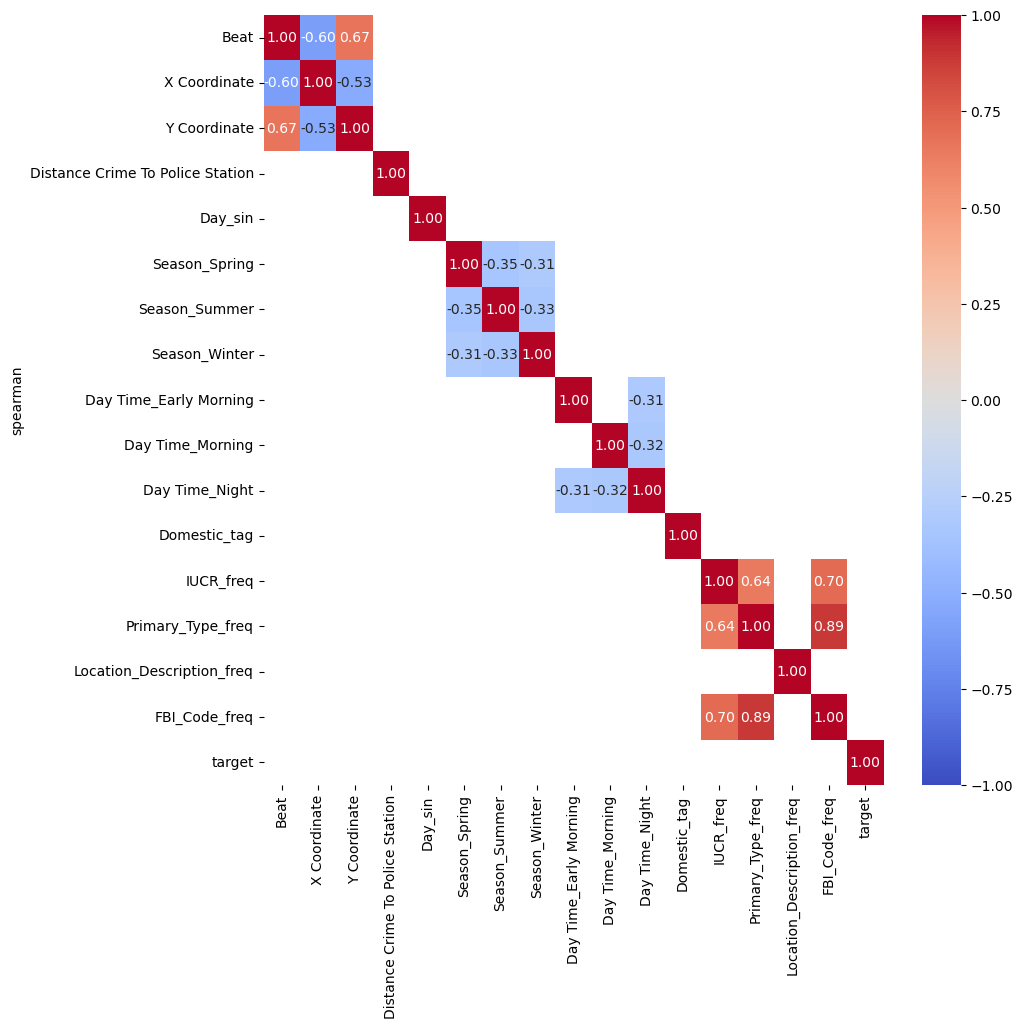

In [78]:
datos_train_corr = X_train_final.copy()
datos_train_corr['target'] = y_train_encoded.copy()


umbral = 0.3
mask_for_heatmap = (datos_train_corr.corr(method='pearson').abs() < umbral)
plt.figure(figsize=(10,10))
sns.heatmap(
    datos_train_corr.corr(method='spearman'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=mask_for_heatmap)
plt.ylabel('spearman')
plt.show()

In [79]:
# Información mutua (todas, fit en train, transformar ambos)
selector_mi = SelectKBest(score_func=mutual_info_classif, k=15) 

# también se puede usar mutual_info_regression para problemas de ese tipo
X_train_best = selector_mi.fit_transform(X_train_final, y_train_encoded) # todos los tipos de features
selected_indices = selector_mi.get_support()
selected_features = X_train_final.columns[selected_indices]
scores = selector_mi.scores_[selected_indices]
print("\nCaracterísticas seleccionadas (Inf. mutua):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

X_test_best = selector_mi.transform(X_test_final)


Características seleccionadas (Inf. mutua):
Beat: 0.0159
X Coordinate: 0.0329
Y Coordinate: 0.0356
Distance Crime To Police Station: 0.0315
Season_Spring: 0.0064
Season_Summer: 0.0078
Season_Winter: 0.0056
Day Time_Early Morning: 0.0044
Day Time_Morning: 0.0044
Day Time_Night: 0.0094
Domestic_tag: 0.0045
IUCR_freq: 0.1461
Primary_Type_freq: 0.1039
Location_Description_freq: 0.0244
FBI_Code_freq: 0.1048


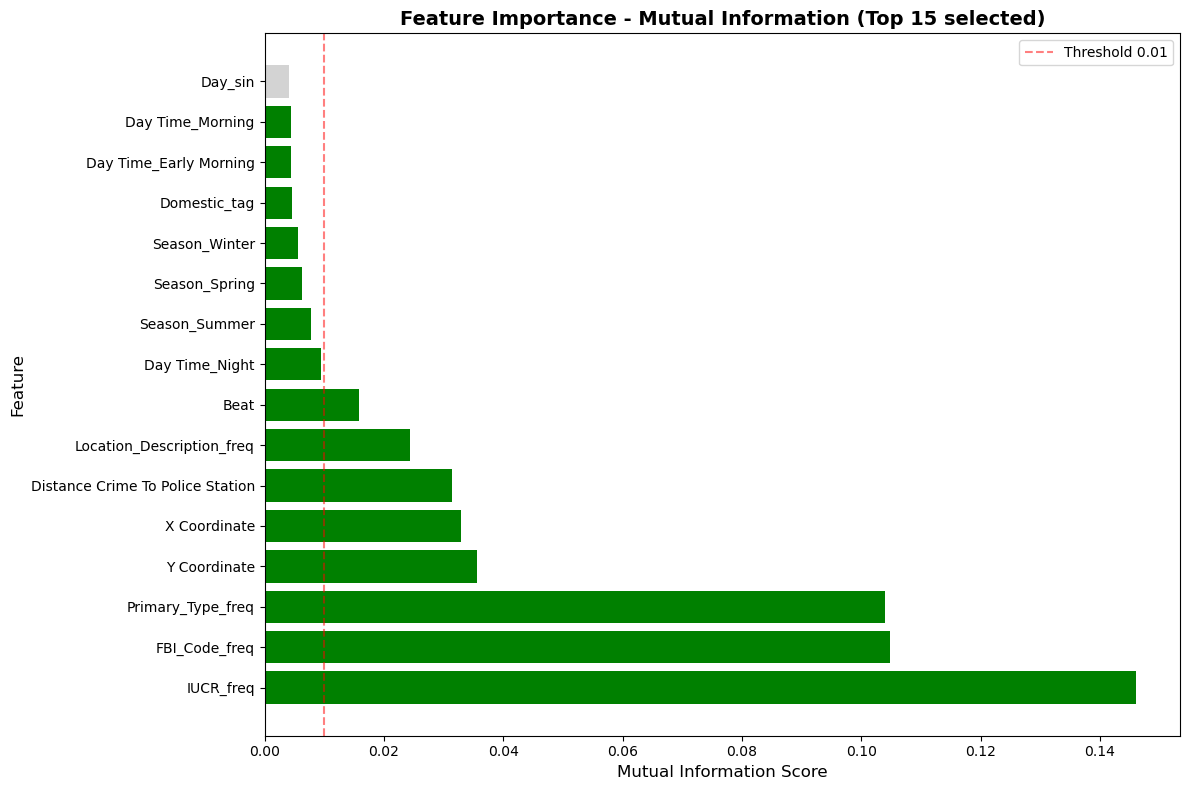


=== TODOS LOS SCORES (ordenados) ===


,Feature,Score,Selected
12,IUCR_freq,0.146097,True
15,FBI_Code_freq,0.104792,True
13,Primary_Type_freq,0.103905,True
2,Y Coordinate,0.035647,True
1,X Coordinate,0.032887,True
3,Distance Crime To Police Station,0.031483,True
14,Location_Description_freq,0.024364,True
0,Beat,0.015909,True
10,Day Time_Night,0.009427,True
6,Season_Summer,0.007785,True


In [80]:
# Crear DataFrame con TODOS los scores (no solo los seleccionados)
all_features = X_train_final.columns
all_scores = selector_mi.scores_

scores_df = pd.DataFrame({
    'Feature': all_features,
    'Score': all_scores,
    'Selected': selector_mi.get_support()
}).sort_values('Score', ascending=False)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if sel else 'lightgray' for sel in scores_df['Selected']]
ax.barh(scores_df['Feature'], scores_df['Score'], color=colors)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title(f'Feature Importance - Mutual Information (Top {selector_mi.k} selected)',
            fontsize=14, fontweight='bold')
ax.axvline(0.01, color='red', linestyle='--', alpha=0.5, label='Threshold 0.01')
ax.legend()
plt.tight_layout()
plt.show()

# Mostrar tabla
print("\n=== TODOS LOS SCORES (ordenados) ===")
display(scores_df)


In [81]:
# 1. FEATURE SELECTION 
selector = SelectKBest(mutual_info_classif, k=20)  # Seleccionar más de las necesarias
X_selected = selector.fit_transform(X_train_final, y_train_encoded)
selected_features = X_train_final.columns[selector.get_support()]

# 2. CORRELACIÓN ENTRE FEATURES SELECCIONADAS (para eliminar redundancia)
# Usar SPEARMAN (no ANOVA - ANOVA no mide correlación entre features)
corr_matrix = X_train_final[selected_features].corr(method='spearman')

# 3. ELIMINAR CORRELACIONADAS (threshold=0.8)
def remove_correlated(corr_matrix, threshold=0.8):
    upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    to_drop = [col for col in corr_matrix.columns
                if any(abs(corr_matrix.loc[col, upper[corr_matrix.columns.get_loc(col)]]) > threshold)]
    return to_drop

to_drop = remove_correlated(corr_matrix, 0.8)
X_final = X_train_final[selected_features].drop(columns=to_drop)

print(f"Features originales: {X_train_final.shape[1]}")
print(f"Después de MI: {len(selected_features)}")
print(f"Después de eliminar correlacionadas: {X_final.shape[1]}")
print(f"Features seleccionadas: {selected_features}")


/opt/homebrew/anaconda3/envs/add-env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=16. All the features will be returned.
  warnings.warn(


Features originales: 16
Después de MI: 16
Después de eliminar correlacionadas: 15
Features seleccionadas: Index(['Beat', 'X Coordinate', 'Y Coordinate',
       'Distance Crime To Police Station', 'Day_sin', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq'],
      dtype='object')


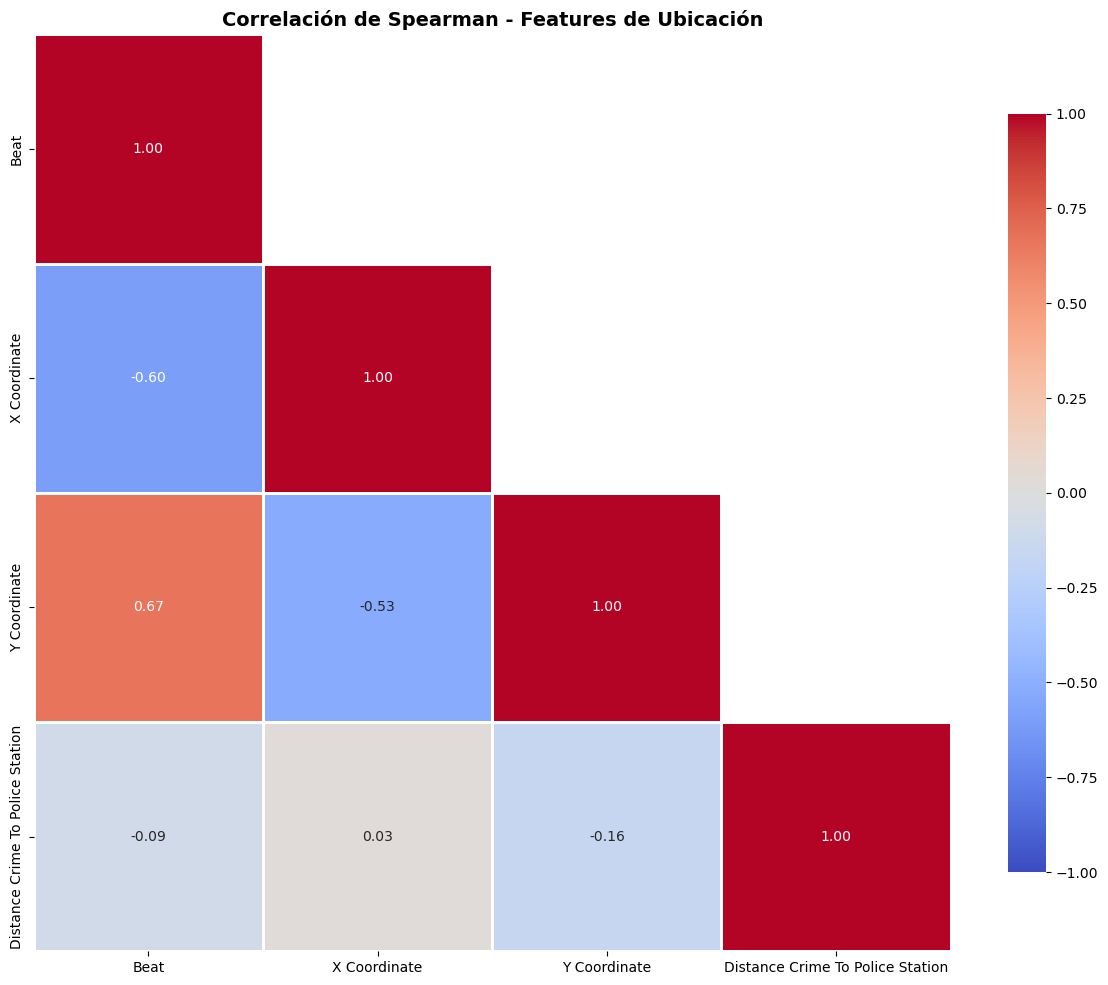

PARES CON CORRELACIÓN > 0.85 (MUY REDUNDANTES)
  Beat                                          ↔ Y Coordinate                                  : 0.666


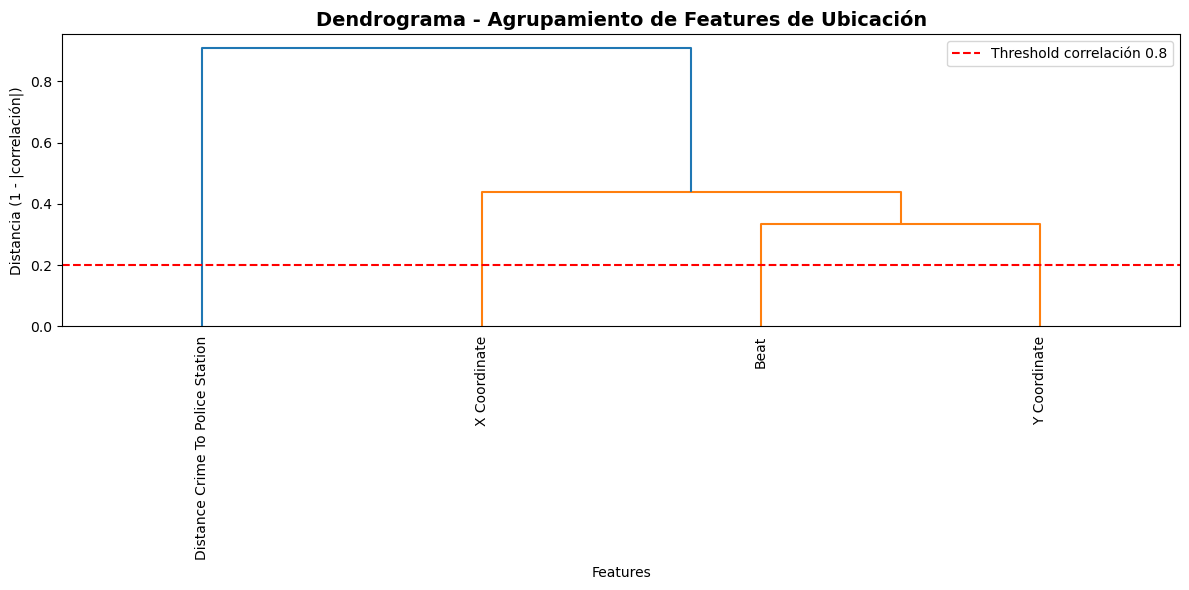

In [82]:
# 1. SELECCIONAR SOLO FEATURES DE UBICACIÓN

location_features = [
    'Beat', 'X Coordinate', 'Y Coordinate',
    'Distance Crime To Police Station',
]

X_location = X_train_final[location_features]

# 2. CALCULAR CORRELACIÓN DE SPEARMAN

corr_location = X_location.corr(method='spearman')

# 3. VISUALIZAR HEATMAP

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_location, dtype=bool), k=1)  # Ocultar triángulo superior

sns.heatmap(corr_location,
            mask=mask,
            annot=True,           # Mostrar valores
            fmt='.2f',            # 2 decimales
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})

plt.title('Correlación de Spearman - Features de Ubicación',
        fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 4. ENCONTRAR PARES MUY CORRELACIONADOS (> 0.85)

print("PARES CON CORRELACIÓN > 0.85 (MUY REDUNDANTES)")


upper_triangle = np.triu(np.ones(corr_location.shape), k=1).astype(bool)
high_corr = []

for i, col in enumerate(corr_location.columns):
    for j, row in enumerate(corr_location.index):
        if upper_triangle[j, i]:
            corr_value = corr_location.iloc[j, i]
            if abs(corr_value) > 0.6:
                high_corr.append({
                    'Feature 1': row,
                    'Feature 2': col,
                    'Correlation': corr_value
                })

high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation',
                                                    key=abs,
                                                    ascending=False)

for _, row in high_corr_df.iterrows():
    print(f"  {row['Feature 1']:45s} ↔ {row['Feature 2']:45s} : {row['Correlation']:.3f}")

# 5. AGRUPAR POR CLUSTERS DE CORRELACIÓN

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Convertir correlación a distancia (1 - |corr|)
distance_matrix = 1 - abs(corr_location)

# Clustering jerárquico
linkage = hierarchy.linkage(squareform(distance_matrix), method='average')

# Visualizar dendrograma
fig, ax = plt.subplots(figsize=(12, 6))
dendro = hierarchy.dendrogram(linkage,
                                labels=corr_location.columns,
                                leaf_rotation=90,
                                leaf_font_size=10)
plt.title('Dendrograma - Agrupamiento de Features de Ubicación',
        fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Distancia (1 - |correlación|)')
plt.axhline(y=0.2, color='red', linestyle='--',
            label='Threshold correlación 0.8')
plt.legend()
plt.tight_layout()
plt.show()